# Indice de contenido
1. [Importar librerias](#il)
2. [Funciones y clases auxiliares](#fca)
3. [Seleccionar camara para capturar imagenes](#sc)
    - 3.1 [Forma automatica](#scfa)
    - 3.2 [Forma manual](#scfm)
4. [Vista previa de la camara](#vpc)
5. [Capturar imagenes del tablero de ajedrez](#ci)
6. [Guardar imagenes](#gi)

# 1. Importar librerias <a class='anchor' id='il'>

In [23]:
import io
import os
import cv2
import time
import numpy as np
import subprocess
import re
import matplotlib
import matplotlib.pyplot as plt
import shutil

%matplotlib inline

In [24]:
# Versiones de los paquetes utilizados
print('Versiones de los paquetes utilizados:')
print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))

Versiones de los paquetes utilizados:
cv2==4.12.0
numpy==2.4.1
re==2.2.1
matplotlib==3.10.8


# 2. Funciones y clases auxiliares <a class='anchor' id='fca'>

In [2]:
# Seleccionar una camara
# NOTA: Solo para sistemas operativos Linux
def select_camera():
    camera_information=None
    # Camaras conectadas via USB 
    # Cada elemento de la lista cuenta con: (Nombre de la camara, Ruta de la camara)
    camera_information_list=get_camera_information_list()
    while camera_information is None:
        print('\n' + 100 * '*')
        print('\nCamaras disponibles: ')
        for i in range(len(camera_information_list)):
            print(f'\t {i + 1}) ', camera_information_list[i])
        option=input('Elige una camara: ')
        if int(option) > 0 and int(option) <= len(camera_information_list):
            camera_information=camera_information_list[int(option) - 1]
            break
    return camera_information

# Obtener informacion de las camaras conectadas via USB
def get_camera_information_list():
    camera_information_list=[]
    res=subprocess.run(["v4l2-ctl", "--list-devices"], capture_output=True, text=True)
    res_split=res.stdout.split("\n\n")[0:-1]
    pattern = "video[0-9]{1}"
    for r in res_split:
        r_split=r.split("\n\t")
        if len(re.findall(pattern, r_split[1]))>0:
            camera_name=r_split[0].split("(")[0].strip() 
            camera_path=r_split[1]
            camera_information_list.append((camera_name, camera_path))
    return camera_information_list

# Muestra la camara y toma una imagen 
def show_camera(camera_information):
    image_bgr=None
    camera_name,camera_path=camera_information
    # Abrimos la camara
    cap=cv2.VideoCapture(camera_path)
    while True:
        try:
            if cap is not None:
                if cap.isOpened():
                    # Captura de la imagen actual de la camara
                    ret, image_bgr=cap.read()
                    # Dimensiones: (height,width,deep)
                    if ret:
                        # Se muestra lo que captura la camara
                        cv2.imshow(camera_name, image_bgr)
                        key=cv2.waitKey(1)
                        
                        # Condicion de parada
                        if key == ord('q'):
                            break 
        except cv2.error as e:
            print("(cv2.error): {}".format(e))
    cap.release()
    cv2.destroyAllWindows()
    return image_bgr

# Toma imagenes cada cierto tiempo
def take_images(camera_information, number_of_images, timer_time):
    # Informacion de la camara
    camera_name,camera_path=camera_information
    # Abrimos la camara
    cap=cv2.VideoCapture(camera_path)
    # Contador de imagenes
    count=1
    # Se inicializa el timer 
    start_t=time.time()
    end_t=time.time()
    # Para guardar las iamgenes tomadas
    image_bgr_list=[]
    while True:
        try:
            if cap is not None:
                if cap.isOpened():
                    # Captura de la imagen actual de la camara
                    ret, image_bgr=cap.read()
                    # Dimensiones: (height,width,deep)
                    if ret:
                        text=f'Tiempo para la foto ({count}/{number_of_images}): {(timer_time - (end_t - start_t)):.2f}'
                        image_bgr_copy=image_bgr.copy()
                        image_bgr_copy=cv2.putText(image_bgr_copy, text, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3, cv2.LINE_AA)

                        # Se muestra lo que captura la camara
                        cv2.imshow(camera_name, image_bgr_copy)
                        key=cv2.waitKey(1)
                        
                        end_t=time.time()
                        # Condicion de parada
                        if key == ord('q') or count > number_of_images:
                            break 
                        # Se cumple el tiempo de guardar la imagen actual
                        if end_t - start_t >= timer_time:
                            image_bgr_list.append(image_bgr)
                            count+=1
                            start_t=end_t
                    else:
                        """
                        Una vez que esta funcionando, si la camara se desconecta entra aqui.
                        Si se vuelve a conectar por USB no se reconecta por si sola.
                        """
                else:
                    """
                    Si la camara no esta conectada por USB desde un inicio entra aqui.
                    Si se vuelve a conectar por USB no se reconecta por si sola.
                    """
            else:
                pass
        except cv2.error as e:
            print("(cv2.error): {}".format(e))
    cap.release()
    cv2.destroyAllWindows()
    return image_bgr_list

# Muestra imagenes
def plot_images(image_bgr_list, figsize=(4,4)):
    for i in range(len(image_bgr_list)):
        image_bgr=image_bgr_list[i]
        image_rgb=cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        fig=plt.figure(figsize=figsize)
        plt.title(f'Imagen {i + 1}')
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.show()

# 3. Seleccionar camara para capturar imagenes <a class='anchor' id='sc'>

Solo elegir una opcion de las siguientes:
- Forma automatica
- Forma manual

## 3.1 Forma automatica <a class='anchor' id='scfa'>

Solo funciona para sistemas operativos Linux.

In [13]:
camera_information=select_camera()
print(f'\nCamara seleccionada: {camera_information}')


****************************************************************************************************

Camaras disponibles: 
	 1)  ('USB PHY 2.0: USB CAMERA', '/dev/video0')
	 2)  ('HX-USB Camera: HX-USB Camera', '/dev/video4')
	 3)  ('EasyCamera: EasyCamera', '/dev/video2')


Elige una camara:  3



Camara seleccionada: ('EasyCamera: EasyCamera', '/dev/video2')


## 3.2 Forma manual <a class='anchor' id='scfm'>

Funciona de forma general para cualquier sistema operativo, solo se requiere especificar un nombre para la camara y la ruta de la camara.

La ruta es la que se pasa como parametro a cv2.VideoCapture(\<camera path\>).

In [11]:
camera_information=(
    'USB PHY 2.0: USB CAMERA', # Nombre de la camara
    '/dev/video0'              # Ruta de la camara
)

# 4. Vista previa de la camara <a class='anchor' id='vpc'>

In [15]:
# Mostrar camara (presionar 'q' para salir)
show_camera(camera_information)

array([[[144, 161,  85],
        [147, 163,  87],
        [148, 164,  89],
        ...,
        [107, 154,  49],
        [111, 152,  56],
        [111, 152,  56]],

       [[145, 163,  87],
        [146, 165,  89],
        [146, 164,  90],
        ...,
        [100, 140,  49],
        [109, 149,  59],
        [112, 152,  61]],

       [[141, 165,  93],
        [142, 166,  94],
        [141, 165,  93],
        ...,
        [101, 138,  41],
        [109, 143,  55],
        [119, 153,  66]],

       ...,

       [[148, 134, 175],
        [148, 134, 175],
        [140, 136, 173],
        ...,
        [ 16,  43,  64],
        [ 17,  43,  68],
        [ 17,  43,  68]],

       [[143, 129, 179],
        [141, 126, 177],
        [139, 133, 173],
        ...,
        [ 19,  47,  60],
        [ 19,  44,  65],
        [ 19,  44,  65]],

       [[144, 123, 179],
        [143, 122, 178],
        [144, 125, 176],
        ...,
        [ 29,  38,  66],
        [ 26,  37,  58],
        [ 25,  36,  57]]

# 5. Capturar imagenes del tablero de ajedrez <a class='anchor' id='ci'>

In [16]:
# Numero de imagenes a tomar
number_of_images=30
# Tiempo en segundos entre cada toma
timer_time=3
# Capturar imagenes
image_bgr_list=take_images(
    camera_information=camera_information, 
    number_of_images=number_of_images, 
    timer_time=timer_time
)

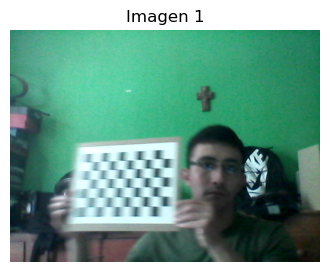

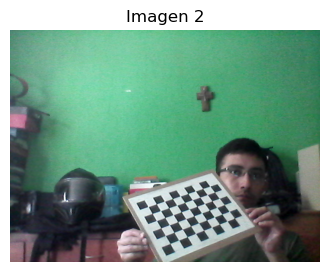

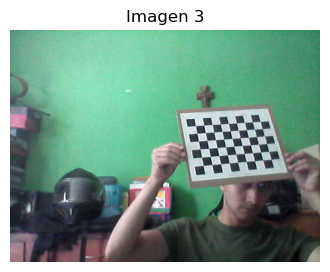

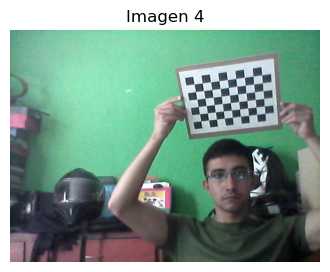

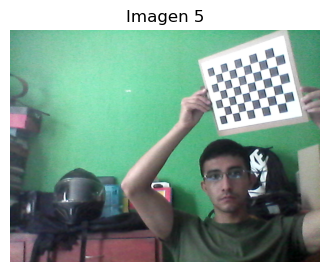

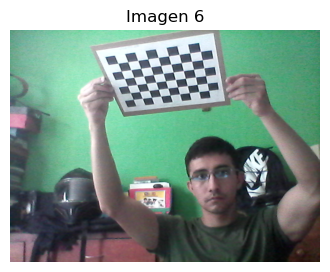

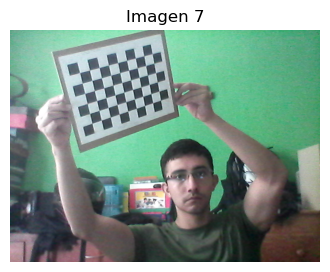

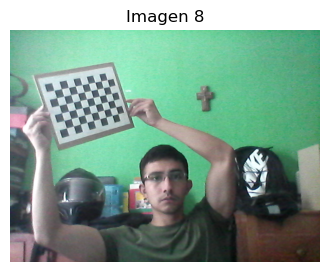

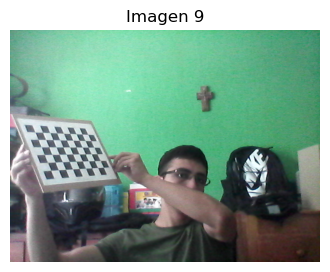

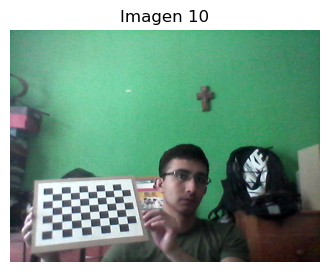

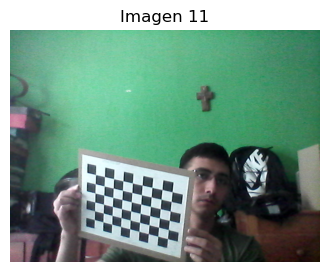

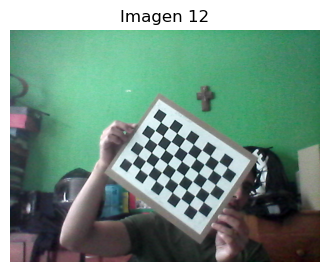

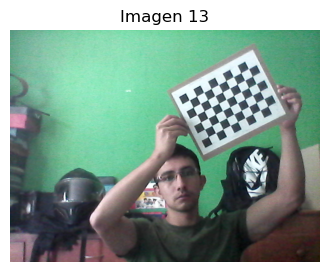

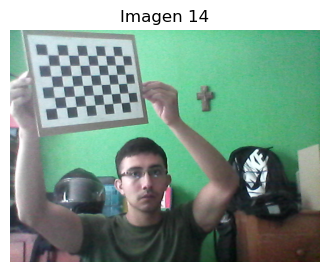

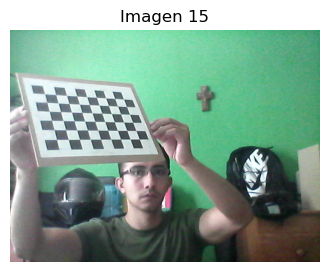

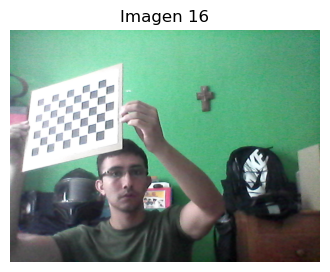

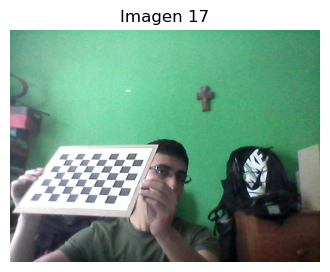

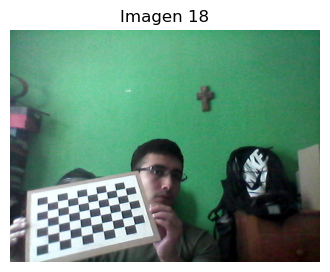

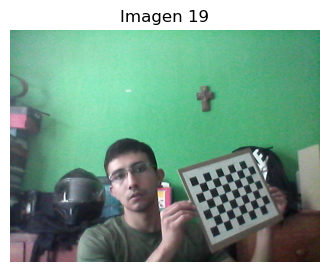

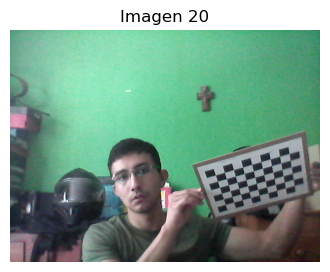

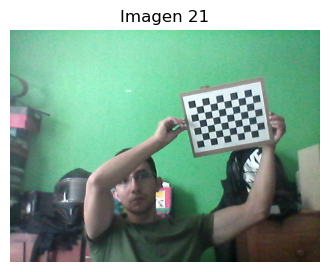

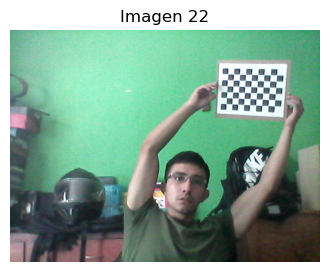

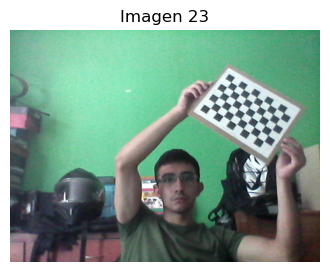

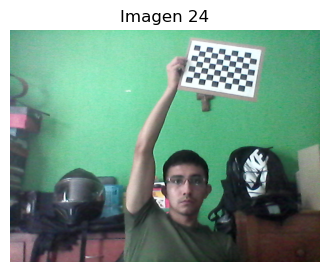

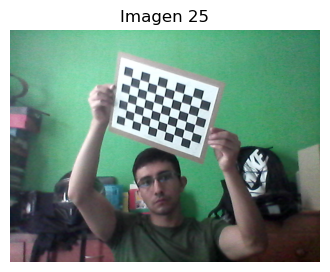

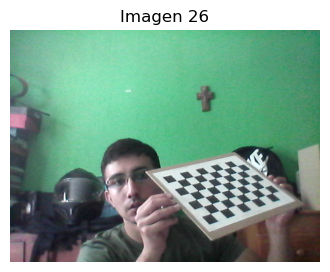

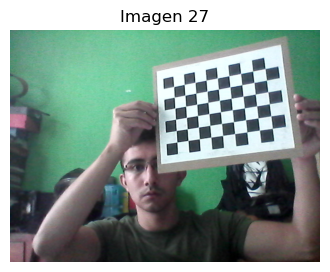

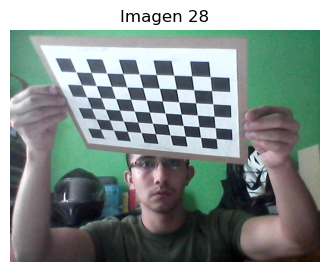

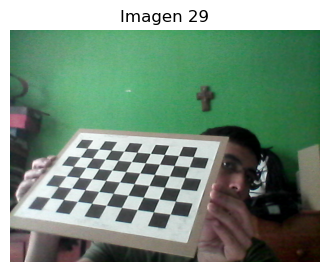

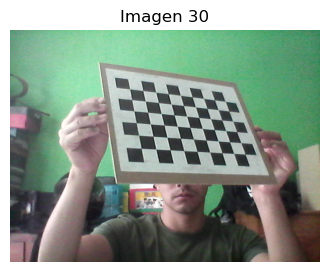

In [17]:
# Imagenes capturadas
plot_images(image_bgr_list, figsize=(4,4))

# 6. Guardar imagenes <a class='anchor' id='gi'>

Las imagenes se guardan en formato JPG en el siguiente directorio:
**./calibration images/\<camera name>**

In [18]:
# Informacion de la camara
camera_name,camera_path=camera_information
# Ruta donde se guardaran las imagenes
folder_name=os.path.join(os.getcwd(), *['calibration images', camera_name])
# Creamos la carpeta si no existe, y limpiamos la carpeta en caso de que exista
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
else:
    shutil.rmtree(folder_name, ignore_errors=True)
    os.makedirs(folder_name)
# Guardamos las imagenes
for i in range(len(image_bgr_list)):
    image_bgr=image_bgr_list[i]
    # Nombre de la imagen
    image_name="img_{}.jpg".format(str(i + 1).zfill(2))
    full_path=os.path.join(folder_name, *[image_name])
    # Se guarda la imagen
    cv2.imwrite(full_path, image_bgr)